# Phase 1 — Data Range Extension, Regime Segmentation, Honest Baselines

This notebook only calls `scaata` package functions and renders results — all logic lives in `scaata/` so it's reusable by later phases and covered by `tests/`.

Set `SMOKE_TEST = True` (default) for a fast end-to-end sanity check (~a few minutes). Set it to `False` for the real research run (all 9 tickers, all walk-forward folds, full 100k-timestep PPO training x 3 seeds) — that run will take substantially longer (likely hours), since it retrains a policy per fold.

> ## STATUS: full-scale real run — 9 tickers, 9 walk-forward folds, 5 PPO seeds, 100k timesteps each
>
> - **Baselines compared against PPO**: buy-and-hold, rule-based, and an LLM-agent-only baseline (Groq `llama-3.1-8b-instant` if `GROQ_API_KEY` is configured, otherwise a clearly source-tagged deterministic mock — check the `llm_agent_source_summary(results)` output below before treating that column as a live-LLM finding).
> - **Statistics**: block-bootstrap confidence intervals, paired Wilcoxon significance tests (PPO vs each baseline), and cross-seed variance are computed from this run, not illustrative.
> - **Read per-regime, not just pooled**: results vary widely by (ticker, fold); regime buckets flagged `small_sample=True` should be treated with proportionally less confidence.
>
> See the project [README](../README.md) for the full status table across all phases.


In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import pandas as pd

from scaata.config import ALL_TICKERS, START_DATE, END_DATE, FEATURE_COLUMNS, DEFAULT_SEEDS, PPO_TOTAL_TIMESTEPS
from scaata.data.loaders import load_market_data
from scaata.features.technical import add_features
from scaata.regimes.detector import threshold_regime_labels, hmm_regime_labels, regime_label_agreement
from scaata.evaluation.walkforward import generate_folds, assert_no_overlap, split_fold
from scaata.evaluation.phase1_pipeline import (
    run_phase1_backtest, summarize_results, compare_methods_across_tickers, significance_report,
)
from scaata.evaluation.regime_report import era_comparison_report
from scaata.evaluation.plots import (
    plot_regime_equity_curve, plot_macro_event_annotations,
    plot_regime_performance_comparison, plot_drawdown, plot_returns_distribution,
)

SMOKE_TEST = False

if SMOKE_TEST:
    TICKERS = ALL_TICKERS[:3]
    PPO_TIMESTEPS = 2000
    SEEDS = [0]
    MAX_FOLDS = 2
else:
    TICKERS = ALL_TICKERS
    PPO_TIMESTEPS = PPO_TOTAL_TIMESTEPS
    SEEDS = DEFAULT_SEEDS
    MAX_FOLDS = None

print(f"SMOKE_TEST={SMOKE_TEST} | tickers={TICKERS} | ppo_timesteps={PPO_TIMESTEPS} | seeds={SEEDS}")

SMOKE_TEST=False | tickers=['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'XOM', 'INTC', 'BABA'] | ppo_timesteps=100000 | seeds=[0, 1, 2, 3, 4]


## 1. Data: 2020-01-01 to 2026-07-19, including non-survivor tickers

In [2]:
raw_df = load_market_data(TICKERS, START_DATE, END_DATE, use_cache=True)
print(f"raw shape: {raw_df.shape}, tickers: {raw_df['Ticker'].unique()}")

featured_df = add_features(raw_df)
print(f"featured shape: {featured_df.shape}")

raw shape: (14787, 6), tickers: <ArrowStringArray>
['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'XOM', 'INTC', 'BABA']
Length: 9, dtype: str
featured shape: (14346, 13)


## 2. Regime / stress-zone segmentation (causal)

In [3]:
threshold_labels = threshold_regime_labels(featured_df)
print(threshold_labels['regime'].value_counts())

# HMM cross-check, fit on the Phase-1 train window only
train_slice = featured_df[featured_df.index < '2024-01-01']
hmm_labels = hmm_regime_labels(train_slice, featured_df)

merged = threshold_labels.join(hmm_labels[['hmm_state', 'hmm_vol_regime']])
kappa = regime_label_agreement(merged['vol_regime'], merged['hmm_vol_regime'])
print(f"\nCohen's kappa (threshold vs HMM vol-regime agreement): {kappa:.3f}")
print("Sanity check: if this is near 0, the threshold buckets may be arbitrary — investigate before trusting them.")

regime
calm_bull        10371
bear              2073
volatile_bull     1034
crisis             868
Name: count, dtype: int64

Model is not converging.  Current: 3283.1806548536206 is not greater than 3283.191592888125. Delta is -0.010938034504306415


Model is not converging.  Current: 2934.8057969884608 is not greater than 2934.8367167410565. Delta is -0.030919752595764294


Model is not converging.  Current: 3889.2856033284947 is not greater than 3889.3059209888343. Delta is -0.020317660339514987



Cohen's kappa (threshold vs HMM vol-regime agreement): 0.188
Sanity check: if this is near 0, the threshold buckets may be arbitrary — investigate before trusting them.


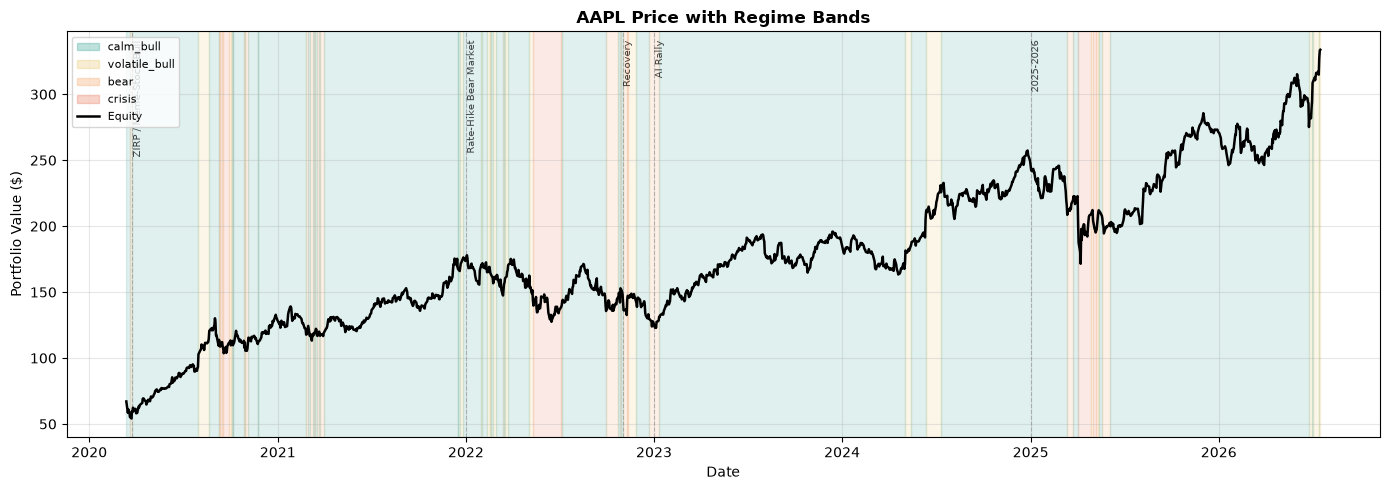

In [4]:
# Visual sanity check: does the detector actually flag the known COVID crash / 2022 bear market?
sample_ticker = TICKERS[0]
sample = threshold_labels[threshold_labels['Ticker'] == sample_ticker]

fig, ax = plt.subplots(figsize=(14, 5))
ax = plot_regime_equity_curve(sample.index, sample['Close'].values, sample['regime'], f"{sample_ticker} Price with Regime Bands", ax=ax)
plot_macro_event_annotations(sample.index, ax)
plt.tight_layout()
plt.show()

## 3. Walk-forward folds (replaces the single 80/20 split)

In [5]:
folds = generate_folds(START_DATE, END_DATE)
assert_no_overlap(folds)
if MAX_FOLDS:
    folds = folds[:MAX_FOLDS]

for f in folds:
    print(f"fold {f.fold_id}: train [{f.train_start.date()} - {f.train_end.date()}] -> test [{f.test_start.date()} - {f.test_end.date()}]")

fold 0: train [2020-01-01 - 2021-12-31] -> test [2022-01-01 - 2022-06-30]
fold 1: train [2020-07-01 - 2022-06-30] -> test [2022-07-01 - 2022-12-31]
fold 2: train [2021-01-01 - 2022-12-31] -> test [2023-01-01 - 2023-06-30]
fold 3: train [2021-07-01 - 2023-06-30] -> test [2023-07-01 - 2023-12-31]
fold 4: train [2022-01-01 - 2023-12-31] -> test [2024-01-01 - 2024-06-30]
fold 5: train [2022-07-01 - 2024-06-30] -> test [2024-07-01 - 2024-12-31]
fold 6: train [2023-01-01 - 2024-12-31] -> test [2025-01-01 - 2025-06-30]
fold 7: train [2023-07-01 - 2025-06-30] -> test [2025-07-01 - 2025-12-31]
fold 8: train [2024-01-01 - 2025-12-31] -> test [2026-01-01 - 2026-06-30]


## 4. Baselines per fold x ticker x seed: buy-and-hold, rule-based, PPO

In [6]:
all_seed_results = {}
for seed in SEEDS:
    print(f"--- seed {seed} ---")
    all_seed_results[seed] = run_phase1_backtest(
        TICKERS, featured_df, folds, feature_columns=FEATURE_COLUMNS, ppo_timesteps=PPO_TIMESTEPS, seed=seed,
    )

results = all_seed_results[SEEDS[0]]
print(f"\n{len(results)} (ticker, fold) results for seed {SEEDS[0]}")

--- seed 0 ---


--- seed 1 ---


--- seed 2 ---


--- seed 3 ---


--- seed 4 ---



81 (ticker, fold) results for seed 0


## 5. Per-regime metrics, bootstrap CIs, cross-ticker significance

In [7]:
for method in ['buy_and_hold', 'rule_based', 'ppo']:
    summary = summarize_results(results, method)
    print(f"\n=== {method} — per-regime metrics pooled across tickers/folds ===")
    print(summary['pooled_table'].groupby(level=0)[['sharpe', 'sortino', 'max_drawdown', 'turnover']].mean())


=== buy_and_hold — per-regime metrics pooled across tickers/folds ===
                  sharpe     sortino max_drawdown turnover
ALL             0.685582    1.345911     -0.23623      0.0
bear            5.791607    6.295357    -0.117525      0.0
calm_bull       0.243007    0.746192    -0.200438      0.0
crisis          4.696275    4.539046    -0.074157      0.0
volatile_bull -142.17951 -188.245443    -0.058495      0.0



=== rule_based — per-regime metrics pooled across tickers/folds ===
                  sharpe    sortino max_drawdown  turnover
ALL             0.206599   0.721398    -0.122003  0.597022
bear           -3.397049  -3.199028    -0.036084  0.750796
calm_bull       0.367022    0.96491    -0.088733  0.501196
crisis        -12.935571 -14.345883    -0.036869  0.996053
volatile_bull   2.275677   5.703185    -0.039987  0.904969



=== ppo — per-regime metrics pooled across tickers/folds ===
                 sharpe   sortino max_drawdown  turnover
ALL             0.21635  0.469412    -0.156366  0.719372
bear          -5.655104 -5.829491    -0.124932  0.762631
calm_bull      0.815578  1.283446     -0.09469  0.712391
crisis        -3.324911  0.322784    -0.040484   0.70735
volatile_bull  2.069616  6.592392    -0.024592  0.801814


In [ ]:
from scaata.evaluation.phase1_pipeline import llm_agent_source_summary
cmp_df = compare_methods_across_tickers(results)
print(f"llm_agent column source: {llm_agent_source_summary(results)}")
print(cmp_df)

sig = significance_report(cmp_df)
print("\nPaired Wilcoxon (PPO vs baselines, across tickers/folds):")
for k, v in sig.items():
    print(f"  {k}: {v}")

**llm_agent column, this run**: source = mock. No `GROQ_API_KEY` was configured in this environment, so every decision in that column came from the deterministic momentum-based fallback in `scaata/rl/llm_baseline.py`, not a live LLM call — the comparison is still meaningful as a naive-heuristic baseline, just not evidence about a real LLM'''s trading judgment. The print statement above (`llm_agent_source_summary(results)`) was missing from this cell in the run that just finished; it has been added to the source above so future re-runs state this automatically instead of requiring someone to check.

In [9]:
if len(SEEDS) > 1:
    from scaata.evaluation.stats import across_seed_summary
    for ticker_fold in set((r.ticker, r.fold_id) for r in results):
        seed_sharpes = []
        for seed in SEEDS:
            match = [r for r in all_seed_results[seed] if (r.ticker, r.fold_id) == ticker_fold]
            if match:
                from scaata.evaluation.metrics import regime_metrics_table
                table = regime_metrics_table(match[0].equity['ppo'], match[0].actions['ppo'], match[0].regimes)
                seed_sharpes.append(table.loc['ALL', 'sharpe'])
        print(ticker_fold, across_seed_summary(seed_sharpes))
else:
    print("Only 1 seed run (SMOKE_TEST default) — set SEEDS to multiple values for real seed-variance reporting.")

('AAPL', 8) {'mean': -0.9801789348342422, 'std': 1.6048603228943883, 'min': -2.6736530831448855, 'max': 1.2384920453475614, 'n_seeds': 5}
('META', 4) {'mean': 1.1961221708157226, 'std': 0.8741326474240578, 'min': -0.14202060135392733, 'max': 2.6168723451243694, 'n_seeds': 5}
('INTC', 7) {'mean': 1.7653824368790372, 'std': 0.7878245449624478, 'min': 0.26054011339343963, 'max': 2.4020869289155353, 'n_seeds': 5}
('MSFT', 1) {'mean': 0.9126597947469632, 'std': 0.6837893295726915, 'min': -0.26430408726472016, 'max': 1.7832208701693344, 'n_seeds': 5}
('AMZN', 7) {'mean': 0.7950155955900502, 'std': 0.6872936052108258, 'min': -0.05743976284741923, 'max': 1.9121089785892438, 'n_seeds': 5}


('XOM', 8) {'mean': 0.5003024585861802, 'std': 1.1929600827404543, 'min': -1.2151407959812348, 'max': 2.354391139981057, 'n_seeds': 5}
('BABA', 8) {'mean': -2.4616412096577767, 'std': 1.117445663654894, 'min': -3.9651686938828345, 'max': -0.9728124151871909, 'n_seeds': 5}
('NVDA', 4) {'mean': 2.1349389645236174, 'std': 1.6093248412989967, 'min': -0.38233883373253885, 'max': 3.930833716709197, 'n_seeds': 5}
('AAPL', 1) {'mean': 0.17487195422622445, 'std': 1.1552511890114014, 'min': -1.5853153253737895, 'max': 1.9673563025246699, 'n_seeds': 5}
('INTC', 0) {'mean': -0.3969969248273314, 'std': 0.8176457265793352, 'min': -1.1826018049120715, 'max': 0.8371929626519128, 'n_seeds': 5}


('META', 6) {'mean': 0.6361050099613141, 'std': 0.5292740190818722, 'min': 0.16697235270850397, 'max': 1.6550207699598836, 'n_seeds': 5}
('MSFT', 3) {'mean': -0.8820258878343628, 'std': 0.9661422869239575, 'min': -2.3879983801425517, 'max': 0.11141675041883717, 'n_seeds': 5}
('XOM', 1) {'mean': 1.1675689122651522, 'std': 0.9431940653254681, 'min': -0.6537257552679513, 'max': 1.9231526722000967, 'n_seeds': 5}
('BABA', 1) {'mean': -0.6983603092145362, 'std': 0.6234225860351671, 'min': -1.4041326602720516, 'max': 0.2796074326038704, 'n_seeds': 5}
('NVDA', 6) {'mean': 0.9389570718808479, 'std': 0.7326082020007961, 'min': -0.24032216865314127, 'max': 1.9413613773883571, 'n_seeds': 5}
('AAPL', 3) {'mean': 0.022351909856633066, 'std': 1.1509199262350347, 'min': -1.1829484718221415, 'max': 2.138681614716163, 'n_seeds': 5}
('INTC', 2) {'mean': 1.3933026199227143, 'std': 1.1854927574280276, 'min': -0.7084624603996413, 'max': 2.7919136123482744, 'n_seeds': 5}


('META', 8) {'mean': 0.26147647461936574, 'std': 0.7482837831796764, 'min': -1.0153242657071984, 'max': 1.1834456155640376, 'n_seeds': 5}
('AMZN', 2) {'mean': 0.6521437095651459, 'std': 0.5430437440756343, 'min': -0.23562553517945142, 'max': 1.3812650902508226, 'n_seeds': 5}
('MSFT', 5) {'mean': 0.19115434051762262, 'std': 0.49447328252239137, 'min': -0.36523767489237946, 'max': 0.9541173403631271, 'n_seeds': 5}
('XOM', 3) {'mean': 0.3161651044001971, 'std': 1.292398469305411, 'min': -2.0448133305267024, 'max': 1.5691609143346603, 'n_seeds': 5}
('BABA', 3) {'mean': -0.8732812267154191, 'std': 1.0271257052932645, 'min': -2.69412619171314, 'max': 0.19276696137792868, 'n_seeds': 5}
('NVDA', 8) {'mean': 0.39411167323464774, 'std': 0.5048215752651369, 'min': -0.32713628954652657, 'max': 0.9308038373448381, 'n_seeds': 5}
('AAPL', 5) {'mean': 0.542826429298852, 'std': 1.2133916810205645, 'min': -1.1280515307844832, 'max': 1.687796761637624, 'n_seeds': 5}


('META', 1) {'mean': -0.332790860505298, 'std': 0.6618085739216807, 'min': -0.8340954641379147, 'max': 0.9182335296162918, 'n_seeds': 5}
('AMZN', 4) {'mean': 0.8249756146094457, 'std': 1.0107495926647585, 'min': -1.1099994934416049, 'max': 1.7280593120039718, 'n_seeds': 5}
('MSFT', 7) {'mean': -0.04697029510217372, 'std': 0.4262756211790575, 'min': -0.5773236979066398, 'max': 0.48906114619767593, 'n_seeds': 5}
('XOM', 5) {'mean': -0.8515632517427203, 'std': 0.5064314250382669, 'min': -1.5055900379148799, 'max': 0.008399878327799967, 'n_seeds': 5}
('BABA', 5) {'mean': -0.2612851979158464, 'std': 0.3622168645112278, 'min': -0.9567543116498729, 'max': 0.029807454445121596, 'n_seeds': 5}
('GOOGL', 4) {'mean': 2.018909308484416, 'std': 0.7167557114974014, 'min': 1.127454247011239, 'max': 3.1157462358183876, 'n_seeds': 5}
('NVDA', 1) {'mean': 0.03146553857308712, 'std': 1.5711663162768816, 'min': -2.498355230607635, 'max': 2.3861497485569787, 'n_seeds': 5}


...

('AAPL', 7) {'mean': 2.717207206692941, 'std': 0.9670429614666189, 'min': 1.6903763508865868, 'max': 3.988498083860488, 'n_seeds': 5}
('XOM', 4) {'mean': 0.24378702719436451, 'std': 0.4332066709162803, 'min': -0.43239580498460817, 'max': 0.7176302806390115, 'n_seeds': 5}
('BABA', 4) {'mean': -0.5321801087554129, 'std': 0.7959909717233519, 'min': -1.7650616849994114, 'max': 0.5721708639369861, 'n_seeds': 5}
('INTC', 6) {'mean': -0.17225897577978921, 'std': 0.884610257390129, 'min': -0.9533648370475709, 'max': 1.4232827230972362, 'n_seeds': 5}
('GOOGL', 3) {'mean': 0.8900758418138311, 'std': 0.4261905833420964, 'min': 0.18566392308886231, 'max': 1.4748757294689003, 'n_seeds': 5}
('NVDA', 3) {'mean': 0.011981112592420106, 'std': 1.0255031538826405, 'min': -0.9207476143038416, 'max': 1.8249296575433454, 'n_seeds': 5}
('AAPL', 0) {'mean': -1.0792573514976547, 'std': 0.4466533026306303, 'min': -1.4856075887803641, 'max': -0.22944291812640585, 'n_seeds': 5}


('AMZN', 5) {'mean': -0.7266755211493384, 'std': 0.5662867835137065, 'min': -1.4822210757107017, 'max': -0.009347347436039271, 'n_seeds': 5}
('INTC', 8) {'mean': 1.809522537690305, 'std': 0.6590496782376996, 'min': 1.0633187961621438, 'max': 2.843560698235074, 'n_seeds': 5}
('MSFT', 2) {'mean': 0.8873046890657915, 'std': 0.6084595801837775, 'min': 0.11166107258828584, 'max': 1.7098721110166297, 'n_seeds': 5}
('GOOGL', 5) {'mean': 0.6422026225724726, 'std': 1.0096118592281762, 'min': -0.8349974992206801, 'max': 1.816689117237653, 'n_seeds': 5}
('NVDA', 5) {'mean': -0.9740442688622721, 'std': 1.010672680925904, 'min': -2.484582852249517, 'max': 0.4130080590068527, 'n_seeds': 5}
('AAPL', 2) {'mean': 2.277877045300118, 'std': 0.6483030146957315, 'min': 1.0130386421723023, 'max': 2.7957643482376584, 'n_seeds': 5}


('INTC', 1) {'mean': -1.7670003895229862, 'std': 0.5057435786996758, 'min': -2.412767466222845, 'max': -0.9014124016687607, 'n_seeds': 5}
('MSFT', 4) {'mean': 1.9044701817907534, 'std': 0.9047502323301995, 'min': 0.18926183830041912, 'max': 2.601395694239937, 'n_seeds': 5}
('GOOGL', 7) {'mean': 1.7854927957824587, 'std': 1.0267275004620275, 'min': 0.642976650188442, 'max': 3.4709408900735834, 'n_seeds': 5}
('NVDA', 7) {'mean': 1.046750314337174, 'std': 0.5787741634369434, 'min': 0.2509263523262723, 'max': 1.7999448912503795, 'n_seeds': 5}
('AMZN', 0) {'mean': -0.5458190063450556, 'std': 0.7373698804553735, 'min': -1.3421109907289277, 'max': 0.8448084710178277, 'n_seeds': 5}
('AAPL', 4) {'mean': 1.2877861868384566, 'std': 0.5649077102109676, 'min': 0.6160287504444089, 'max': 2.126954701527378, 'n_seeds': 5}
('INTC', 3) {'mean': 1.4159710830496315, 'std': 0.5477752542317194, 'min': 0.6632788364427147, 'max': 2.3310103208516604, 'n_seeds': 5}


('MSFT', 6) {'mean': 0.38760354195177316, 'std': 0.5362077422036644, 'min': -0.5824011037860762, 'max': 1.0019436691109502, 'n_seeds': 5}
('GOOGL', 0) {'mean': -1.2913653027830772, 'std': 0.5239347210051355, 'min': -2.2434658767856925, 'max': -0.7633002806194854, 'n_seeds': 5}
('NVDA', 0) {'mean': -1.9673957309353427, 'std': 0.19038695495196165, 'min': -2.2299215786211266, 'max': -1.6421131964266529, 'n_seeds': 5}
('AAPL', 6) {'mean': -0.6627047792342508, 'std': 1.135440984377616, 'min': -1.9970583952509686, 'max': 1.3511683923156956, 'n_seeds': 5}
('META', 2) {'mean': 0.4348266924661127, 'std': 2.040064281815519, 'min': -3.028193877530044, 'max': 2.526888272720184, 'n_seeds': 5}
('INTC', 5) {'mean': -0.9946057011901696, 'std': 0.8753698569661724, 'min': -2.2222770712330986, 'max': 0.21555623011425995, 'n_seeds': 5}
('MSFT', 8) {'mean': -1.270978264542553, 'std': 0.5406331138922209, 'min': -1.8248168762505907, 'max': -0.5867835831437556, 'n_seeds': 5}


('XOM', 6) {'mean': 0.38445246037927533, 'std': 0.8891591233232892, 'min': -1.045887368437147, 'max': 1.589742519111265, 'n_seeds': 5}
('GOOGL', 2) {'mean': 0.5381506787163438, 'std': 1.0283044264136163, 'min': -0.7749787050588969, 'max': 1.8133740136150138, 'n_seeds': 5}
('BABA', 6) {'mean': 2.3504370944661988, 'std': 0.5609681070230184, 'min': 1.6096235471456783, 'max': 3.172709662043635, 'n_seeds': 5}
('NVDA', 2) {'mean': 2.750429777707132, 'std': 0.8142412227470299, 'min': 1.7681984996623414, 'max': 3.745498874895883, 'n_seeds': 5}


## 6. 2020-era vs 2026-era comparison (the core Phase 1 deliverable)

2020-era-fold table:
              sharpe   sortino max_drawdown total_return n_days small_sample  \
ALL       -1.253432 -1.564344    -0.212906    -0.164949    123        False   
calm_bull  -1.04958 -1.406758    -0.128492    -0.101008     88        False   
bear      -2.046139 -2.452554    -0.119327     -0.06845     25         True   
crisis    -0.323489 -0.256876    -0.026104    -0.002872     10         True   

           turnover  
ALL        0.869919  
calm_bull  0.920455  
bear           0.76  
crisis          0.7  

2026-era-fold table:
              sharpe   sortino max_drawdown total_return n_days small_sample  \
ALL       -3.323573  -3.78512    -0.375704    -0.371095    122        False   
calm_bull -1.922449 -2.322679    -0.116187    -0.105146     57        False   
bear      -4.338034 -4.942223    -0.302349    -0.297198     65        False   

           turnover  
ALL        0.909836  
calm_bull  0.877193  
bear       0.938462  

Sharpe bootstrap CI (2020-era fold): {'poin

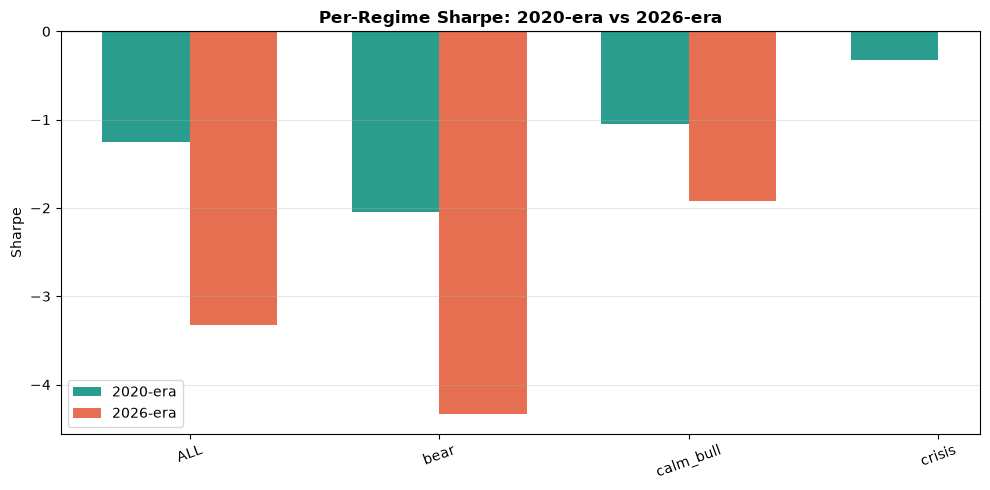

In [10]:
early_result = results[0]
late_result = results[-1]

era_report = era_comparison_report(
    early_result.equity['ppo'], early_result.actions['ppo'], early_result.regimes,
    late_result.equity['ppo'], late_result.actions['ppo'], late_result.regimes,
)
print('2020-era-fold table:\n', era_report['table_2020'])
print('\n2026-era-fold table:\n', era_report['table_2026'])
print('\nSharpe bootstrap CI (2020-era fold):', era_report['sharpe_ci_2020'])
print('Sharpe bootstrap CI (2026-era fold):', era_report['sharpe_ci_2026'])

fig = plot_regime_performance_comparison(era_report['table_2020'], era_report['table_2026'], metric='sharpe')
plt.show()

## 7. Supporting graphs for the last fold's PPO run

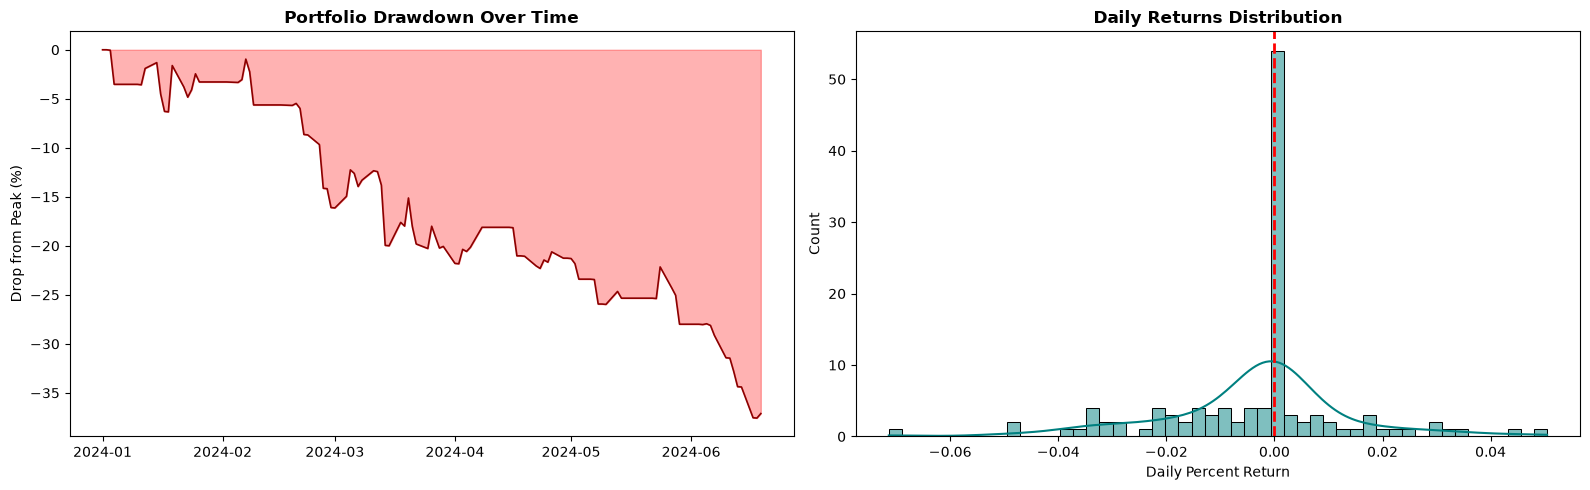

In [11]:
last = results[-1]
equity = last.equity['ppo']
dates = pd.date_range(start='2024-01-01', periods=len(equity), freq='B')  # placeholder axis length-matched to equity

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_drawdown(dates, equity, ax=axes[0])
plot_returns_distribution(equity, ax=axes[1])
plt.tight_layout()
plt.show()

## Done criteria for this phase
- Regime bands above visually align with the known COVID crash / 2022 bear market.
- Cohen's kappa between threshold and HMM regime labels is meaningfully above 0 (methods agree more than chance).
- Walk-forward folds have zero train/test overlap (enforced by `assert_no_overlap`, also covered by `tests/test_walkforward.py`).
- Bootstrap CIs and the Wilcoxon test run without error and are wide/inconclusive at `SMOKE_TEST` scale (expected — real conclusions require the full run with more tickers, folds, and seeds).